**Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

LOading the dataset

In [5]:
df = sns.load_dataset("titanic")


In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
df.drop(["embarked","class","alive"],axis =1 , inplace = True)

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,True,NaN,Southampton,True


In [10]:
null_num = []
for i in df.columns:
    x = df[i].isnull().sum()
    null_num.append(x)

In [11]:
null_num

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(177),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(688),
 np.int64(2),
 np.int64(0)]

In [12]:
pd.DataFrame(null_num,index = df.columns,columns=["Total Missing Values"])

,Total Missing Values
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
who,0
adult_male,0
deck,688


<Axes: xlabel='deck', ylabel='count'>

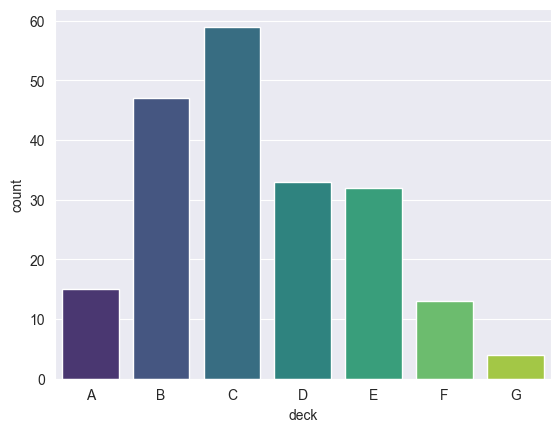

In [13]:
sns.set_style("darkgrid")
sns.countplot(x = "deck",data = df,palette="viridis")

<Axes: xlabel='deck', ylabel='count'>

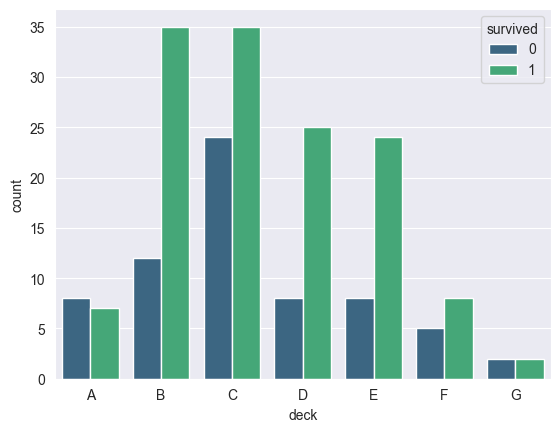

In [15]:
sns.set_style("darkgrid")
sns.countplot(x = "deck",hue="survived",
data = df,palette="viridis")

In [16]:
df.drop(["deck"], axis=1, inplace=True)

In [17]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True


<Axes: xlabel='pclass', ylabel='age'>

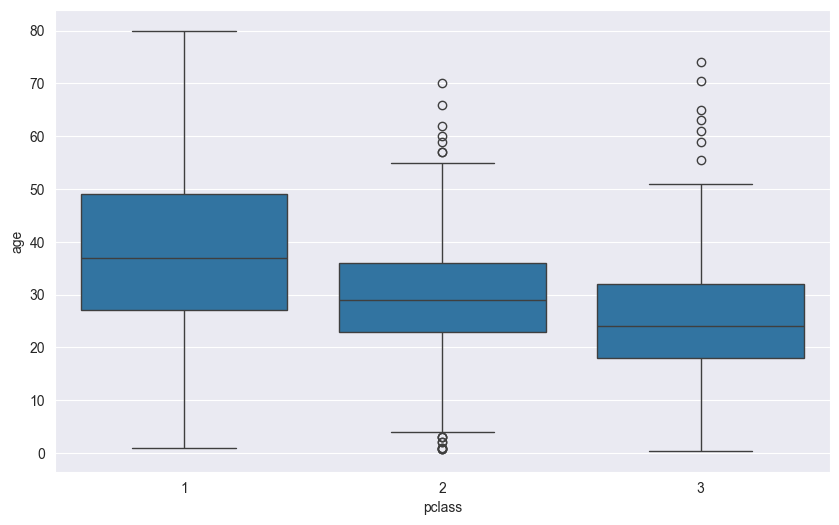

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x = "pclass",y = "age", data = df)

In [27]:
def fillna_age(columns):
    age = columns["age"]
    pclass = columns["pclass"]
    
    if pd.isnull(age):
        if pclass == 1:
            return 38
        elif pclass == 2:
            return 29
        else:
            return 23
    else:
        return age

In [28]:
df["age"] = df.apply(fillna_age, axis=1)

In [29]:
null_num = []
for i in df.columns:
    x = df[i].isnull().sum()
    null_num.append(x)

pd.DataFrame(null_num,index = df.columns,columns=["Total Missing Values"])


,Total Missing Values
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
who,0
adult_male,0
embark_town,2


In [30]:
df.dropna(inplace=True)

In [31]:
null_num = []
for i in df.columns:
    x = df[i].isnull().sum()
    null_num.append(x)

pd.DataFrame(null_num,index = df.columns,columns=["Total Missing Values"])

,Total Missing Values
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
who,0
adult_male,0
embark_town,0


<Axes: xlabel='survived', ylabel='count'>

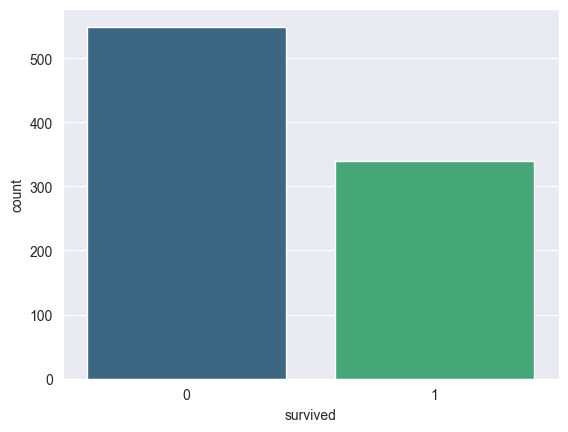

In [32]:
sns.set_style("darkgrid")
sns.countplot(x = "survived",data = df,palette="viridis")

In [33]:
df.survived.value_counts()

survived
0    549
1    340
Name: count, dtype: int64

<Axes: xlabel='survived', ylabel='count'>

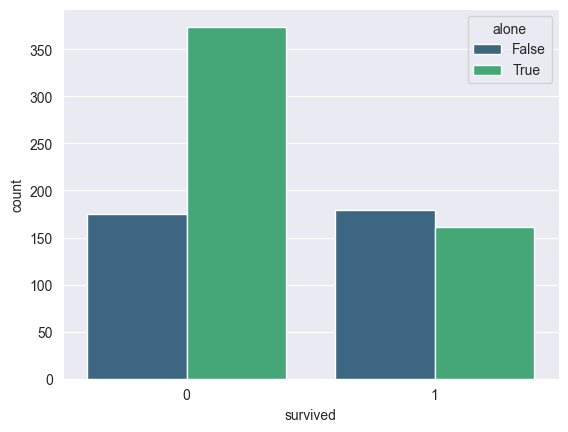

In [34]:
sns.set_style("darkgrid")
sns.countplot(x = "survived",hue = "alone",data = df,palette="viridis")

<Axes: xlabel='survived', ylabel='count'>

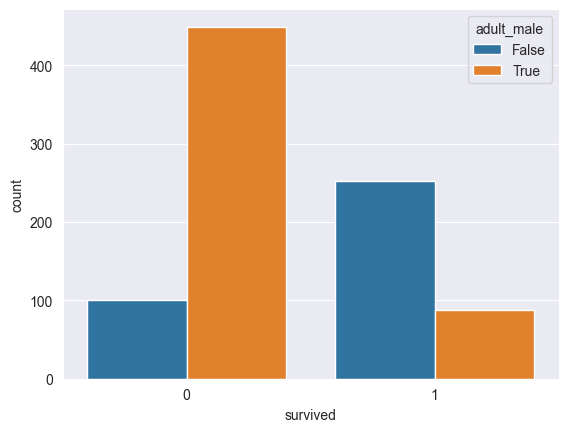

In [36]:
sns.set_style("darkgrid")
sns.countplot(x = "survived",hue = "adult_male",data = df)

<Axes: xlabel='survived', ylabel='count'>

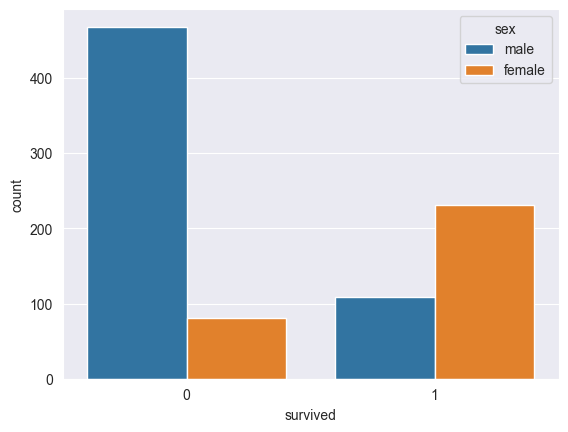

In [37]:
sns.set_style("darkgrid")
sns.countplot(x = "survived",hue = "sex",data = df)

<Axes: xlabel='survived', ylabel='count'>

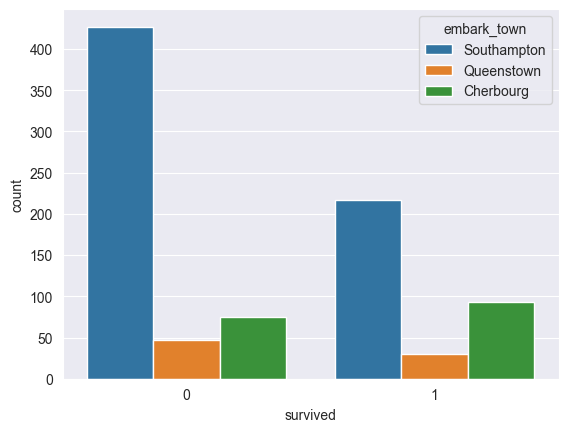

In [39]:
sns.set_style("darkgrid")
sns.countplot(x = "survived",hue = "embark_town",data = df)

In [40]:
df.embark_town.value_counts()


embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Count'>

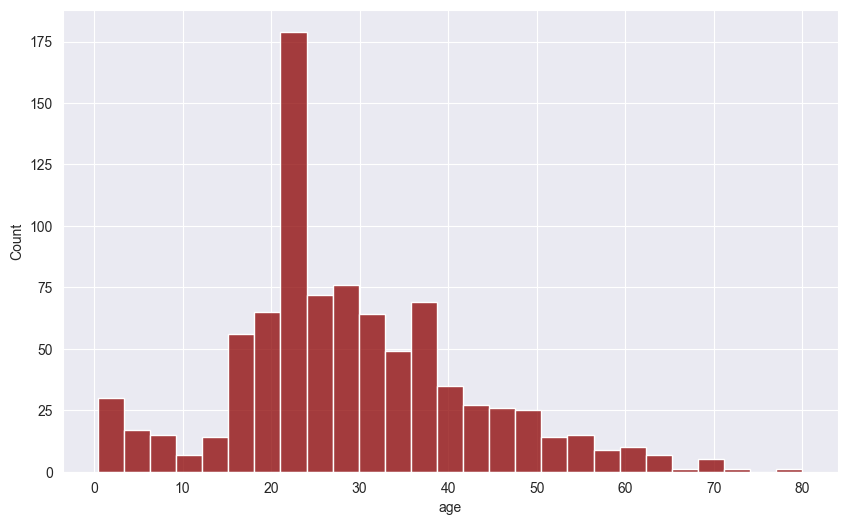

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df["age"], color="darkred")

<Axes: xlabel='fare', ylabel='Density'>

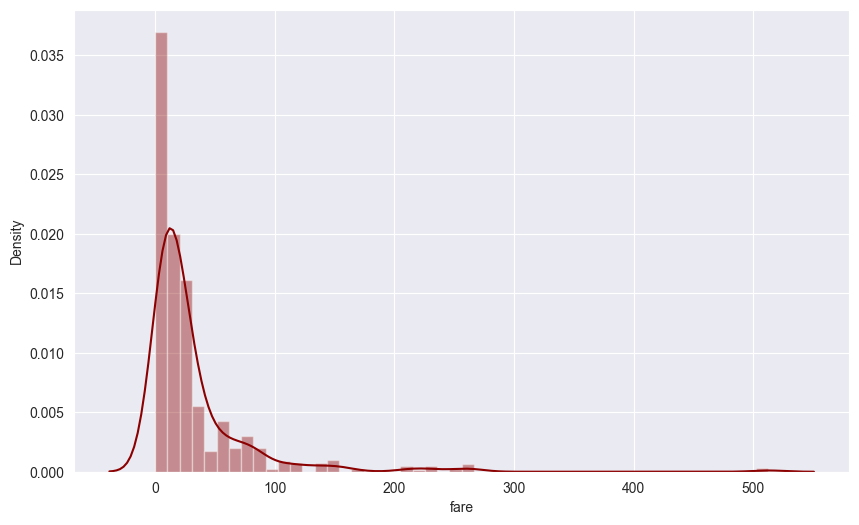

In [46]:
plt.figure(figsize=(10,6))
sns.distplot(df["fare"],color = "darkred")

<Axes: >

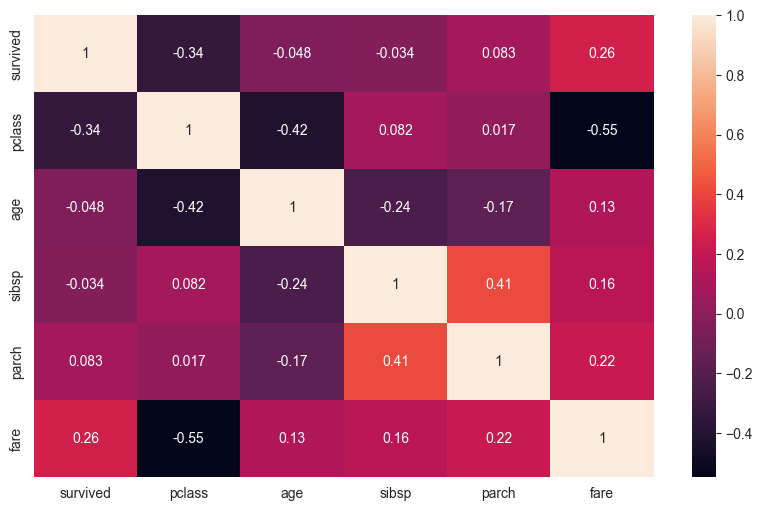

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)

In [51]:
df.drop(["age","sibsp","parch"], axis=1, inplace=True)

In [52]:
df.head()

,survived,pclass,sex,fare,who,adult_male,embark_town,alone
0,0,3,male,7.2500,man,True,Southampton,False
1,1,1,female,71.2833,woman,False,Cherbourg,False
2,1,3,female,7.9250,woman,False,Southampton,True
3,1,1,female,53.1000,woman,False,Southampton,False
4,0,3,male,8.0500,man,True,Southampton,True


In [59]:
sex = pd.get_dummies(df["sex"], drop_first=True)
who = pd.get_dummies(df["who"], drop_first=True)
adult_male = pd.get_dummies(df["adult_male"], drop_first=True)
embark_town = pd.get_dummies(df["embark_town"], drop_first=True)
alone = pd.get_dummies(df["alone"], drop_first=True)

# Combine original data with one-hot encoded columns after all variables are defined.
df = pd.concat([df, sex, who, adult_male, embark_town, alone], axis=1)